# Gradient Boosting Quality Benchmark: Scantec Contamination Dataset

## Why This Dataset?

The Scantec DeepScan contamination dataset represents a **real-world imbalanced classification problem** in waste management:

- **Task**: Predict bio waste contamination from geodemographic features
- **Challenge**: Severe class imbalance (~7% positive rate)
- **Business Value**: Target education campaigns to high-risk areas

### Key Characteristics

| Property | Value |
|----------|-------|
| Rows | ~2,848 (after joining) |
| Features | ~149 (all numeric geodemographic) |
| Target | Binary (contaminated: Rot vs not) |
| Positive Rate | ~7.2% |
| Primary Metric | **ROC-AUC** (due to imbalance) |

### Data Sources

1. **Scantec DeepScan**: Optical contamination measurements from waste collection vehicles
2. **Post Direkt**: Geodemographic features (purchasing power, demographics, consumer behavior)

### Models Compared

1. Decision Tree (baseline)
2. Random Forest
3. GradientBoosting (vanilla sklearn)
4. HistGradientBoosting (sklearn histogram-based)
5. XGBoost
6. LightGBM
7. CatBoost

**Note**: Since all features are numeric, we don't need separate native categorical vs encoded comparisons.

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================
import pandas as pd
import numpy as np
import time
import warnings
import gc
import re
from pathlib import Path
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    log_loss, roc_auc_score, roc_curve,
    brier_score_loss, precision_recall_curve, average_precision_score,
    classification_report, f1_score, confusion_matrix,
    accuracy_score, precision_score, recall_score
)
from sklearn.calibration import calibration_curve

# Models - Classic
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Models - Histogram-based / Advanced GBDT
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

# CatBoost (optional - may not be available on all systems)
try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    print("CatBoost not available - skipping CatBoost models")

# Statistical analysis
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
print("Imports complete.")
print(f"CatBoost available: {CATBOOST_AVAILABLE}")

Imports complete.
CatBoost available: True


## Configuration

Configure data paths, model hyperparameters, and output settings.

In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Data paths
SCANTEC_PATH = Path("data/Scantec/TourdetailsFES-DeepScan.csv")
POST_DIREKT_PATH = Path("data/Post Direkt/post.csv")

# Output directory
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Train/test split (stratified due to class imbalance)
TEST_SIZE = 0.2
VAL_SIZE = 0.15  # From training set, for early stopping

# Model hyperparameters
MAX_ITERATIONS = 200  # More iterations for small dataset
MAX_DEPTH = 6
LEARNING_RATE = 0.1
EARLY_STOPPING_ROUNDS = 20
RANDOM_STATE = 42

# GPU Configuration (set to True if you have CUDA-enabled GPU)
USE_GPU = False

print("Configuration:")
print(f"  Max Iterations: {MAX_ITERATIONS}")
print(f"  Max Depth: {MAX_DEPTH}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Early Stopping: {EARLY_STOPPING_ROUNDS} rounds")
print(f"  Test Size: {TEST_SIZE*100:.0f}%")
print(f"  Validation Size: {VAL_SIZE*100:.0f}% (from training)")
print(f"  GPU: {USE_GPU}")

Configuration:
  Max Iterations: 200
  Max Depth: 6
  Learning Rate: 0.1
  Early Stopping: 20 rounds
  Test Size: 20%
  Validation Size: 15% (from training)
  GPU: False


## Data Loading

Load Scantec contamination data and Post Direkt geodemographic features.

In [3]:
# Load Scantec data (skip first 15 header/summary rows)
scantec = pd.read_csv(
    SCANTEC_PATH,
    sep=";",
    skiprows=15,
    encoding="utf-8"
)

print(f"Scantec records: {len(scantec):,}")
print(f"\nColumns: {list(scantec.columns)}")
print(f"\nBewertung (contamination rating) distribution:")
print(scantec['Bewertung'].value_counts())

Scantec records: 2,848

Columns: ['Datum', 'Zeit', 'RFID', 'Grenzwerte', 'Fahrzeug', 'Geleert', 'Liftertyp', 'Tour', 'Bewertung', 'Messwert', 'Straße', 'Hausnummer', 'Ort', 'PLZ', 'Bundesland', 'Land']

Bewertung (contamination rating) distribution:
Bewertung
Grün    2605
Rot      204
Gelb      26
Grau      13
Name: count, dtype: int64


In [4]:
# Load Post Direkt geodemographic data
post = pd.read_csv(POST_DIREKT_PATH, low_memory=False)

print(f"Post Direkt records: {len(post):,}")
print(f"Total columns: {len(post.columns)}")
print(f"\nSample columns: {list(post.columns[:15])}...")

Post Direkt records: 90,313
Total columns: 169

Sample columns: ['ID_AGS', 'Strasse', 'Hausnummer', 'Hausnummernzusatz', 'PLZ', 'Ort', 'Ortsteil', 'Kaufkraft', 'Kaufkraft (gewichtet)', 'Alter auf Gebäudeebene', 'Anteil Familien', 'Kleinkinder', 'Anteil Singles', 'Fluktuation', 'Wohndauer']...


## Data Preprocessing

### Key preprocessing steps:
1. **Normalize street names** for joining (handle German abbreviations)
2. **Aggregate Post Direkt** to street+PLZ level (mean of numeric features)
3. **Join datasets** on normalized street + PLZ
4. **Create binary target**: `is_contaminated = (Bewertung == 'Rot')`
5. **Handle missing values** with median imputation

In [5]:
def normalize_street_name(street: str) -> str:
    """
    Normalize German street names for joining.
    Handles: "Str." -> "straße", "Strasse" -> "straße", lowercase, whitespace
    """
    if pd.isna(street):
        return ""
    s = str(street).lower().strip()
    s = s.replace("str.", "straße").replace("strasse", "straße")
    s = s.replace("  ", " ")
    return s

def sanitize_column_name(name):
    """Sanitize column names for LightGBM (remove special JSON characters)."""
    return re.sub(r'[^\w\s]', '_', str(name)).replace(' ', '_')

# ID/address columns to exclude from features
POST_DIREKT_ID_COLS = {
    "ID_AGS", "Strasse", "Hausnummer", "Hausnummernzusatz",
    "PLZ", "Ort", "Ortsteil", "MB_HA_ID"
}

# Identify and convert to numeric feature columns
feature_cols = [c for c in post.columns if c not in POST_DIREKT_ID_COLS]
for col in feature_cols:
    post[col] = pd.to_numeric(post[col], errors='coerce')

# Keep only numeric columns
numeric_features = [c for c in feature_cols if post[c].dtype in ('float64', 'int64')]
print(f"Numeric geodemographic features: {len(numeric_features)}")

Numeric geodemographic features: 161


In [6]:
# Normalize join keys in Post Direkt
post['_street_norm'] = post['Strasse'].apply(normalize_street_name)
post['_plz'] = post['PLZ'].astype(str).str.strip()

# Aggregate to street+PLZ level (mean of numeric features)
agg_dict = {col: 'mean' for col in numeric_features if col in post.columns}
post_agg = post.groupby(['_street_norm', '_plz']).agg(agg_dict).reset_index()

print(f"Post Direkt aggregated to street+PLZ: {len(post_agg):,} unique combinations")

Post Direkt aggregated to street+PLZ: 3,111 unique combinations


In [7]:
# Normalize join keys in Scantec
scantec['_street_norm'] = scantec['Straße'].apply(normalize_street_name)
scantec['_plz'] = scantec['PLZ'].astype(str).str.strip()

# Create binary target: is_contaminated (Rot = contaminated)
scantec['is_contaminated'] = (scantec['Bewertung'] == 'Rot').astype(int)

print(f"Target distribution:")
print(scantec['is_contaminated'].value_counts(normalize=True))
print(f"\nContamination rate: {scantec['is_contaminated'].mean()*100:.2f}%")

Target distribution:
is_contaminated
0    0.928371
1    0.071629
Name: proportion, dtype: float64

Contamination rate: 7.16%


In [8]:
# Join Scantec with Post Direkt
df = scantec.merge(
    post_agg,
    on=['_street_norm', '_plz'],
    how='left',
    indicator=True
)

# Check join success rate
matched = (df['_merge'] == 'both').sum()
print(f"Join success: {matched:,} / {len(scantec):,} ({matched/len(scantec)*100:.1f}%)")

# Filter to matched records only
df = df[df['_merge'] == 'both'].copy()
df = df.drop(columns=['_merge', '_street_norm', '_plz'])

print(f"\nFinal dataset: {len(df):,} records")

Join success: 2,840 / 2,848 (99.7%)

Final dataset: 2,840 records


In [9]:
# Select only numeric geodemographic features that exist after join
available_features = [c for c in numeric_features if c in df.columns]

# Remove constant columns (no variance)
constant_cols = [c for c in available_features if df[c].nunique() <= 1]
print(f"Constant features removed: {len(constant_cols)}")
available_features = [c for c in available_features if c not in constant_cols]

# Check missing values
missing_pct = df[available_features].isnull().mean().sort_values(ascending=False)
high_missing = missing_pct[missing_pct > 0.5]
if len(high_missing) > 0:
    print(f"Features with >50% missing (dropped): {len(high_missing)}")
    available_features = [c for c in available_features if c not in high_missing.index]

print(f"\nFinal feature count: {len(available_features)}")

Constant features removed: 12

Final feature count: 149


In [10]:
# Prepare feature matrix and target
X = df[available_features].copy()
y = df['is_contaminated'].values

# Fill remaining missing values with median
for col in X.columns:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())

# Store original names for feature importance interpretation
original_feature_names = list(X.columns)

# Sanitize column names for LightGBM
X.columns = [sanitize_column_name(c) for c in X.columns]
feature_name_mapping = dict(zip(X.columns, original_feature_names))
feature_names = list(X.columns)

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution: {np.bincount(y)}")
print(f"Class imbalance: {y.mean()*100:.2f}% positive (contaminated)")

Feature matrix shape: (2840, 149)
Target distribution: [2636  204]
Class imbalance: 7.18% positive (contaminated)


## Train/Test Split

Use stratified split to preserve class imbalance in both sets.

**Note**: Unlike the Criteo dataset, Scantec data is not temporally ordered, so we use random stratified split.

In [11]:
# Stratified train/test split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

# Split training into train + validation (for early stopping)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print(f"Train set: {X_train.shape[0]} samples ({y_train.mean()*100:.2f}% positive)")
print(f"Val set:   {X_val.shape[0]} samples ({y_val.mean()*100:.2f}% positive)")
print(f"Test set:  {X_test.shape[0]} samples ({y_test.mean()*100:.2f}% positive)")

# Free memory
del X_temp, y_temp
gc.collect()

Train set: 1931 samples (7.20% positive)
Val set:   341 samples (7.04% positive)
Test set:  568 samples (7.22% positive)


567

## Baseline Metrics

Before training models, establish what a naive predictor would achieve.

**Critical for imbalanced data**: Baseline accuracy is ~93% by always predicting "not contaminated".
We need ROC-AUC to measure actual model discrimination ability.

In [12]:
# Baseline: predict constant contamination rate (mean of training data)
baseline_proba = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
baseline_logloss = log_loss(y_test, baseline_proba)
baseline_auc = 0.5  # Random guessing

# Baseline accuracy (always predict majority class)
baseline_accuracy = max(np.mean(y_test == 0), np.mean(y_test == 1))

print("="*60)
print("BASELINE: Constant Contamination Rate Predictor")
print("="*60)
print(f"  Predicts P(contaminated) = {y_train.mean():.4f} for all samples")
print(f"  LogLoss:  {baseline_logloss:.5f}")
print(f"  AUC:      {baseline_auc:.5f} (random guessing)")
print(f"  Accuracy: {baseline_accuracy:.4f} (always predict 'not contaminated')")
print(f"\nAll models should beat AUC > {baseline_auc} and LogLoss < {baseline_logloss:.5f}")

BASELINE: Constant Contamination Rate Predictor
  Predicts P(contaminated) = 0.0720 for all samples
  LogLoss:  0.25925
  AUC:      0.50000 (random guessing)
  Accuracy: 0.9278 (always predict 'not contaminated')

All models should beat AUC > 0.5 and LogLoss < 0.25925


In [13]:
# Results storage
results = []
trained_models = {}  # Store trained models for feature importance
eval_histories = {}  # Store training history for convergence plots
y_probas = {}  # Store predictions for all models

def evaluate_model(y_true, y_proba, model_name, train_time, n_iterations=None):
    """Calculate and store metrics for a model."""
    y_pred = (y_proba >= 0.5).astype(int)
    
    logloss = log_loss(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    result = {
        'Model': model_name,
        'LogLoss': logloss,
        'AUC': auc,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Train Time (s)': round(train_time, 2),
        'Iterations': n_iterations
    }
    
    # Store probabilities
    y_probas[model_name] = y_proba
    
    print(f"  LogLoss:  {logloss:.5f}")
    print(f"  AUC:      {auc:.5f}")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Recall:   {recall:.4f}")
    print(f"  Time:     {train_time:.2f}s")
    if n_iterations:
        print(f"  Iterations: {n_iterations}")
    
    return result

## Model 1: Decision Tree (Baseline)

In [14]:
print("="*60)
print("Training Decision Tree (baseline)...")
print("="*60)

dt = DecisionTreeClassifier(
    max_depth=MAX_DEPTH,
    random_state=RANDOM_STATE
)

start = time.time()
dt.fit(X_train, y_train)
train_time = time.time() - start

y_proba = dt.predict_proba(X_test)[:, 1]
results.append(evaluate_model(y_test, y_proba, 'Decision Tree', train_time))
trained_models['Decision Tree'] = dt

gc.collect()

Training Decision Tree (baseline)...
  LogLoss:  0.60790
  AUC:      0.63088
  Accuracy: 0.9225
  Recall:   0.0244
  Time:     0.02s


0

## Model 2: Random Forest

In [15]:
print("="*60)
print("Training Random Forest...")
print("="*60)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=MAX_DEPTH,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

start = time.time()
rf.fit(X_train, y_train)
train_time = time.time() - start

y_proba = rf.predict_proba(X_test)[:, 1]
results.append(evaluate_model(y_test, y_proba, 'Random Forest', train_time))
trained_models['Random Forest'] = rf

gc.collect()

Training Random Forest...
  LogLoss:  0.25589
  AUC:      0.64884
  Accuracy: 0.9278
  Recall:   0.0244
  Time:     0.09s


48

## Model 3: Vanilla GradientBoosting (sklearn)

In [16]:
print("="*60)
print("Training Vanilla GradientBoosting (sklearn)...")
print("Note: No histogram binning - slower but exact")
print("="*60)

gb = GradientBoostingClassifier(
    n_estimators=MAX_ITERATIONS,
    max_depth=MAX_DEPTH,
    learning_rate=LEARNING_RATE,
    random_state=RANDOM_STATE,
    validation_fraction=VAL_SIZE,
    n_iter_no_change=EARLY_STOPPING_ROUNDS
)

start = time.time()
gb.fit(X_train, y_train)
train_time = time.time() - start

y_proba = gb.predict_proba(X_test)[:, 1]
results.append(evaluate_model(y_test, y_proba, 'GradientBoosting', train_time, gb.n_estimators_))
trained_models['GradientBoosting'] = gb

gc.collect()

Training Vanilla GradientBoosting (sklearn)...
Note: No histogram binning - slower but exact
  LogLoss:  0.26259
  AUC:      0.64660
  Accuracy: 0.9278
  Recall:   0.0244
  Time:     0.29s
  Iterations: 21


0

## Model 4: HistGradientBoosting (sklearn)

In [17]:
print("="*60)
print("Training HistGradientBoosting (sklearn)...")
print("="*60)

hgb = HistGradientBoostingClassifier(
    max_iter=MAX_ITERATIONS,
    max_depth=MAX_DEPTH,
    learning_rate=LEARNING_RATE,
    early_stopping=True,
    validation_fraction=VAL_SIZE,
    n_iter_no_change=EARLY_STOPPING_ROUNDS,
    random_state=RANDOM_STATE
)

start = time.time()
hgb.fit(X_train, y_train)
train_time = time.time() - start

y_proba = hgb.predict_proba(X_test)[:, 1]
results.append(evaluate_model(y_test, y_proba, 'HistGradientBoosting', train_time, hgb.n_iter_))
trained_models['HistGradientBoosting'] = hgb

gc.collect()

Training HistGradientBoosting (sklearn)...
  LogLoss:  0.28065
  AUC:      0.60816
  Accuracy: 0.9278
  Recall:   0.0244
  Time:     0.10s
  Iterations: 28


24

## Model 5: XGBoost

In [18]:
print("="*60)
print("Training XGBoost...")
print("="*60)

xgb_params = {
    'n_estimators': MAX_ITERATIONS,
    'max_depth': MAX_DEPTH,
    'learning_rate': LEARNING_RATE,
    'random_state': RANDOM_STATE,
    'tree_method': 'hist',
    'early_stopping_rounds': EARLY_STOPPING_ROUNDS,
    'eval_metric': 'logloss',
    'n_jobs': -1
}
if USE_GPU:
    xgb_params['device'] = 'cuda'
    print("  (Using GPU)")

xgb = XGBClassifier(**xgb_params)

start = time.time()
xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)
train_time = time.time() - start

# Store eval history
eval_histories['XGBoost'] = xgb.evals_result()

y_proba = xgb.predict_proba(X_test)[:, 1]
n_iter = xgb.best_iteration if hasattr(xgb, 'best_iteration') else MAX_ITERATIONS
results.append(evaluate_model(y_test, y_proba, 'XGBoost', train_time, n_iter))
trained_models['XGBoost'] = xgb

gc.collect()

Training XGBoost...
  LogLoss:  0.25096
  AUC:      0.63137
  Accuracy: 0.9278
  Recall:   0.0000
  Time:     0.67s
  Iterations: 11


19

## Model 6: LightGBM

In [19]:
print("="*60)
print("Training LightGBM...")
print("="*60)

lgbm_params = {
    'n_estimators': MAX_ITERATIONS,
    'max_depth': MAX_DEPTH,
    'learning_rate': LEARNING_RATE,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbose': -1
}
if USE_GPU:
    lgbm_params['device'] = 'gpu'
    print("  (Using GPU)")

lgbm = LGBMClassifier(**lgbm_params)

start = time.time()
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric='logloss',
    callbacks=[early_stopping(EARLY_STOPPING_ROUNDS), log_evaluation(0)]
)
train_time = time.time() - start

# Store eval history
eval_histories['LightGBM'] = lgbm.evals_result_

y_proba = lgbm.predict_proba(X_test)[:, 1]
n_iter = lgbm.best_iteration_ if hasattr(lgbm, 'best_iteration_') else MAX_ITERATIONS
results.append(evaluate_model(y_test, y_proba, 'LightGBM', train_time, n_iter))
trained_models['LightGBM'] = lgbm

gc.collect()

Training LightGBM...
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[10]	training's binary_logloss: 0.212704	valid_1's binary_logloss: 0.234121
  LogLoss:  0.24993
  AUC:      0.64588
  Accuracy: 0.9278
  Recall:   0.0000
  Time:     0.09s
  Iterations: 10


249

## Model 7: CatBoost (Optional)

In [20]:
if CATBOOST_AVAILABLE:
    print("="*60)
    print("Training CatBoost...")
    print("="*60)

    catboost_params = {
        'iterations': MAX_ITERATIONS,
        'depth': MAX_DEPTH,
        'learning_rate': LEARNING_RATE,
        'random_state': RANDOM_STATE,
        'early_stopping_rounds': EARLY_STOPPING_ROUNDS,
        'verbose': 0
    }
    if USE_GPU:
        catboost_params['task_type'] = 'GPU'
        print("  (Using GPU)")

    catboost = CatBoostClassifier(**catboost_params)

    start = time.time()
    catboost.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        use_best_model=True
    )
    train_time = time.time() - start

    # Store eval history
    eval_histories['CatBoost'] = catboost.get_evals_result()

    y_proba = catboost.predict_proba(X_test)[:, 1]
    n_iter = catboost.best_iteration_ if hasattr(catboost, 'best_iteration_') else MAX_ITERATIONS
    results.append(evaluate_model(y_test, y_proba, 'CatBoost', train_time, n_iter))
    trained_models['CatBoost'] = catboost

    gc.collect()
else:
    print("Skipping CatBoost (not installed)")

Training CatBoost...
  LogLoss:  0.24773
  AUC:      0.65902
  Accuracy: 0.9278
  Recall:   0.0244
  Time:     0.16s
  Iterations: 28


## Results Comparison

In [21]:
# Create comparison dataframe
results_df = pd.DataFrame(results)

# Sort by AUC (primary metric for imbalanced data)
results_df = results_df.sort_values('AUC', ascending=False).reset_index(drop=True)

# Calculate improvement vs worst
worst_auc = results_df['AUC'].min()
results_df['vs Worst (%)'] = ((results_df['AUC'] - worst_auc) / worst_auc * 100).round(2)

print("="*80)
print("MODEL COMPARISON - Scantec Contamination Prediction")
print(f"Primary metric: ROC-AUC (due to class imbalance)")
print(f"Baseline AUC (random): {baseline_auc}")
print(f"Baseline Accuracy (majority class): {baseline_accuracy:.4f}")
print("="*80)
display(results_df)

MODEL COMPARISON - Scantec Contamination Prediction
Primary metric: ROC-AUC (due to class imbalance)
Baseline AUC (random): 0.5
Baseline Accuracy (majority class): 0.9278


,Model,LogLoss,AUC,Accuracy,Precision,Recall,F1,Train Time (s),Iterations,vs Worst (%)
0,CatBoost,0.247728,0.659023,0.927817,0.5,0.02439,0.046512,0.16,28.0,8.36
1,Random Forest,0.255887,0.648841,0.927817,0.5,0.02439,0.046512,0.09,NaN,6.69
2,GradientBoosting,0.262593,0.646596,0.927817,0.5,0.02439,0.046512,0.29,21.0,6.32
3,LightGBM,0.249927,0.645879,0.927817,0.0,0.00000,0.000000,0.09,10.0,6.20
4,XGBoost,0.250960,0.631369,0.927817,0.0,0.00000,0.000000,0.67,11.0,3.82
5,Decision Tree,0.607904,0.630884,0.922535,0.2,0.02439,0.043478,0.02,NaN,3.74
6,HistGradientBoosting,0.280648,0.608159,0.927817,0.5,0.02439,0.046512,0.10,28.0,0.00


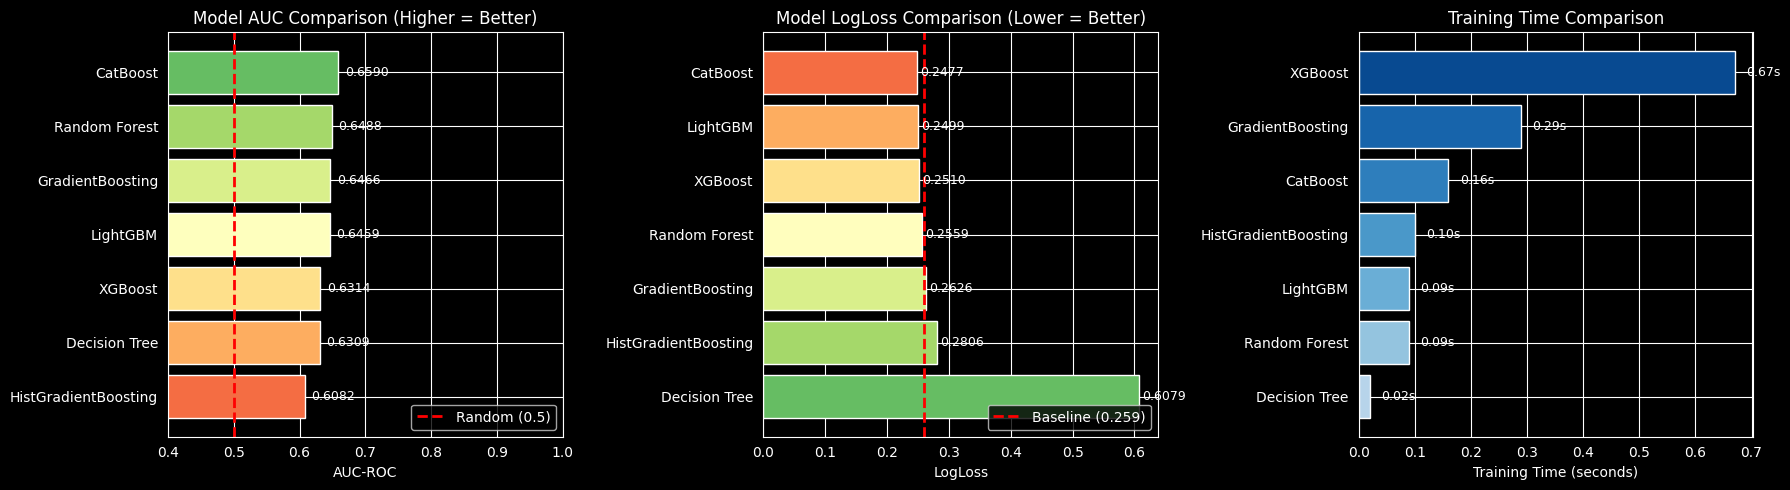

In [22]:
# Visualization: AUC and LogLoss comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# AUC comparison (higher is better)
ax1 = axes[0]
auc_sorted = results_df.sort_values('AUC', ascending=True)
colors1 = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(auc_sorted)))
bars1 = ax1.barh(auc_sorted['Model'], auc_sorted['AUC'], color=colors1)
ax1.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Random (0.5)')
ax1.set_xlabel('AUC-ROC')
ax1.set_title('Model AUC Comparison (Higher = Better)')
ax1.legend(loc='lower right')
ax1.set_xlim(0.4, 1.0)
for bar, auc in zip(bars1, auc_sorted['AUC']):
    ax1.text(auc + 0.01, bar.get_y() + bar.get_height()/2, f'{auc:.4f}', va='center', fontsize=9)

# LogLoss comparison (lower is better)
ax2 = axes[1]
ll_sorted = results_df.sort_values('LogLoss', ascending=False)
colors2 = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(ll_sorted)))
bars2 = ax2.barh(ll_sorted['Model'], ll_sorted['LogLoss'], color=colors2)
ax2.axvline(x=baseline_logloss, color='red', linestyle='--', linewidth=2, label=f'Baseline ({baseline_logloss:.3f})')
ax2.set_xlabel('LogLoss')
ax2.set_title('Model LogLoss Comparison (Lower = Better)')
ax2.legend(loc='lower right')
for bar, ll in zip(bars2, ll_sorted['LogLoss']):
    ax2.text(ll + 0.005, bar.get_y() + bar.get_height()/2, f'{ll:.4f}', va='center', fontsize=9)

# Training time comparison
ax3 = axes[2]
time_sorted = results_df.sort_values('Train Time (s)', ascending=True)
colors3 = plt.cm.Blues(np.linspace(0.3, 0.9, len(time_sorted)))
bars3 = ax3.barh(time_sorted['Model'], time_sorted['Train Time (s)'], color=colors3)
ax3.set_xlabel('Training Time (seconds)')
ax3.set_title('Training Time Comparison')
for bar, t in zip(bars3, time_sorted['Train Time (s)']):
    ax3.text(t + 0.02, bar.get_y() + bar.get_height()/2, f'{t:.2f}s', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()

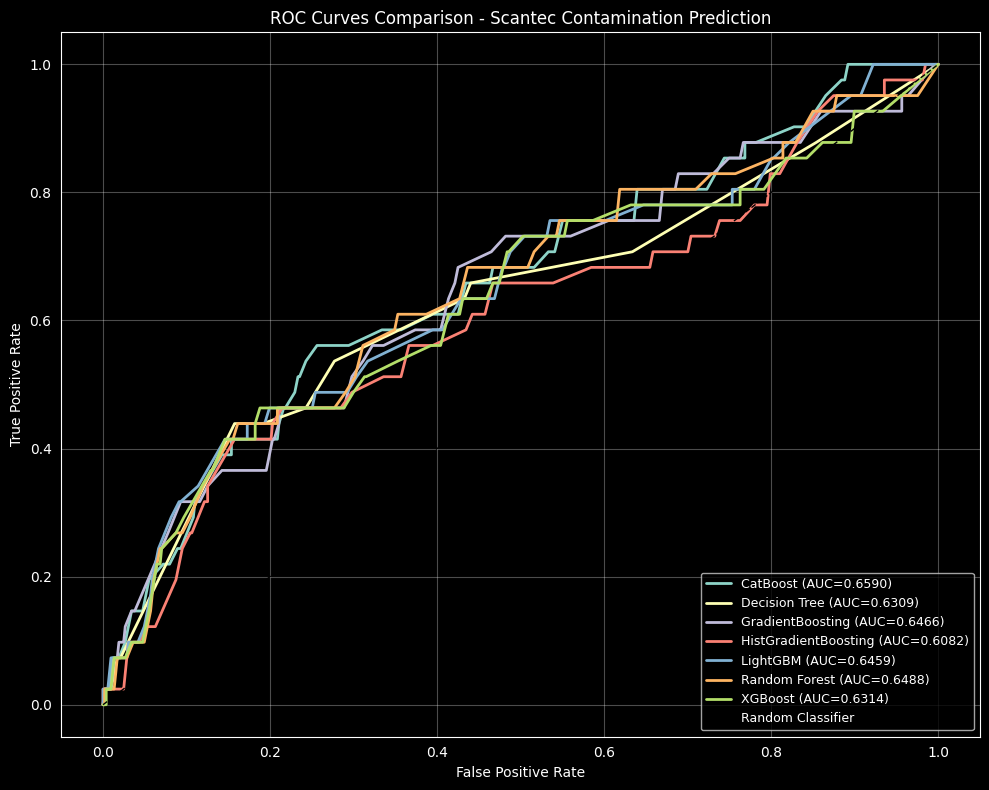

In [23]:
# ROC Curves Comparison
fig, ax = plt.subplots(figsize=(10, 8))

# Plot ROC curve for each model
for model_name, y_proba in sorted(y_probas.items()):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.4f})', linewidth=2)

# Random classifier baseline
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves Comparison - Scantec Contamination Prediction')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Save results to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Add baseline to results for complete picture
results_with_baseline = results_df.copy()
baseline_row = pd.DataFrame([{
    'Model': 'Baseline (constant)',
    'LogLoss': baseline_logloss,
    'AUC': baseline_auc,
    'Accuracy': baseline_accuracy,
    'Precision': 0,
    'Recall': 0,
    'F1': 0,
    'Train Time (s)': 0,
    'Iterations': None,
    'vs Worst (%)': 0.0
}])
results_with_baseline = pd.concat([results_with_baseline, baseline_row], ignore_index=True)
results_with_baseline = results_with_baseline.sort_values('AUC', ascending=False).reset_index(drop=True)

output_file = OUTPUT_DIR / f"scantec_benchmark_{timestamp}.csv"
results_with_baseline.to_csv(output_file, index=False)

print(f"Results saved to: {output_file}")
print(f"\nFull comparison (including baseline):")
display(results_with_baseline)

Results saved to: outputs/scantec_benchmark_20260120_180618.csv

Full comparison (including baseline):


,Model,LogLoss,AUC,Accuracy,Precision,Recall,F1,Train Time (s),Iterations,vs Worst (%)
0,CatBoost,0.247728,0.659023,0.927817,0.5,0.02439,0.046512,0.16,28.0,8.36
1,Random Forest,0.255887,0.648841,0.927817,0.5,0.02439,0.046512,0.09,NaN,6.69
2,GradientBoosting,0.262593,0.646596,0.927817,0.5,0.02439,0.046512,0.29,21.0,6.32
3,LightGBM,0.249927,0.645879,0.927817,0.0,0.00000,0.000000,0.09,10.0,6.20
4,XGBoost,0.250960,0.631369,0.927817,0.0,0.00000,0.000000,0.67,11.0,3.82
5,Decision Tree,0.607904,0.630884,0.922535,0.2,0.02439,0.043478,0.02,NaN,3.74
6,HistGradientBoosting,0.280648,0.608159,0.927817,0.5,0.02439,0.046512,0.10,28.0,0.00
7,Baseline (constant),0.259250,0.500000,0.927817,0.0,0.00000,0.000000,0.00,NaN,0.00


## Key Findings

### Interpretation Guide

For this imbalanced dataset (~7% positive rate):

| Metric | Interpretation |
|--------|----------------|
| **Accuracy** | Misleading - baseline is 93% by always predicting negative |
| **ROC-AUC** | Primary metric - measures discrimination regardless of threshold |
| **Recall** | How many contaminated bins we actually detect |
| **Precision** | Of predicted contaminated, how many truly are |

### AUC Interpretation

| AUC Range | Meaning |
|-----------|----------|
| 0.5 | Random guessing - geodemographics don't help |
| 0.5-0.6 | Slight signal in geodemographics |
| 0.6-0.7 | Moderate predictive power |
| 0.7-0.8 | Good predictive power |
| > 0.8 | Strong predictive power |

---

# Extended Analysis

The following sections provide deeper analysis of model behavior, calibration, and statistical significance.

---

## 1. Feature Importance Analysis

Compare how different models rank feature importance. Do they agree on what geodemographic factors predict contamination?

In [25]:
# Extract feature importance from all models
feature_importance_dict = {}

for model_name, model in trained_models.items():
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
        feature_importance_dict[model_name] = importance
    elif hasattr(model, 'get_feature_importance'):
        # CatBoost
        importance = model.get_feature_importance()
        feature_importance_dict[model_name] = importance

# Create DataFrame
fi_df = pd.DataFrame(feature_importance_dict, index=feature_names)
fi_df = fi_df.div(fi_df.sum())  # Normalize to sum to 1

print(f"Feature importance extracted for {len(feature_importance_dict)} models")
print(f"Features: {len(feature_names)}")

Feature importance extracted for 6 models
Features: 149


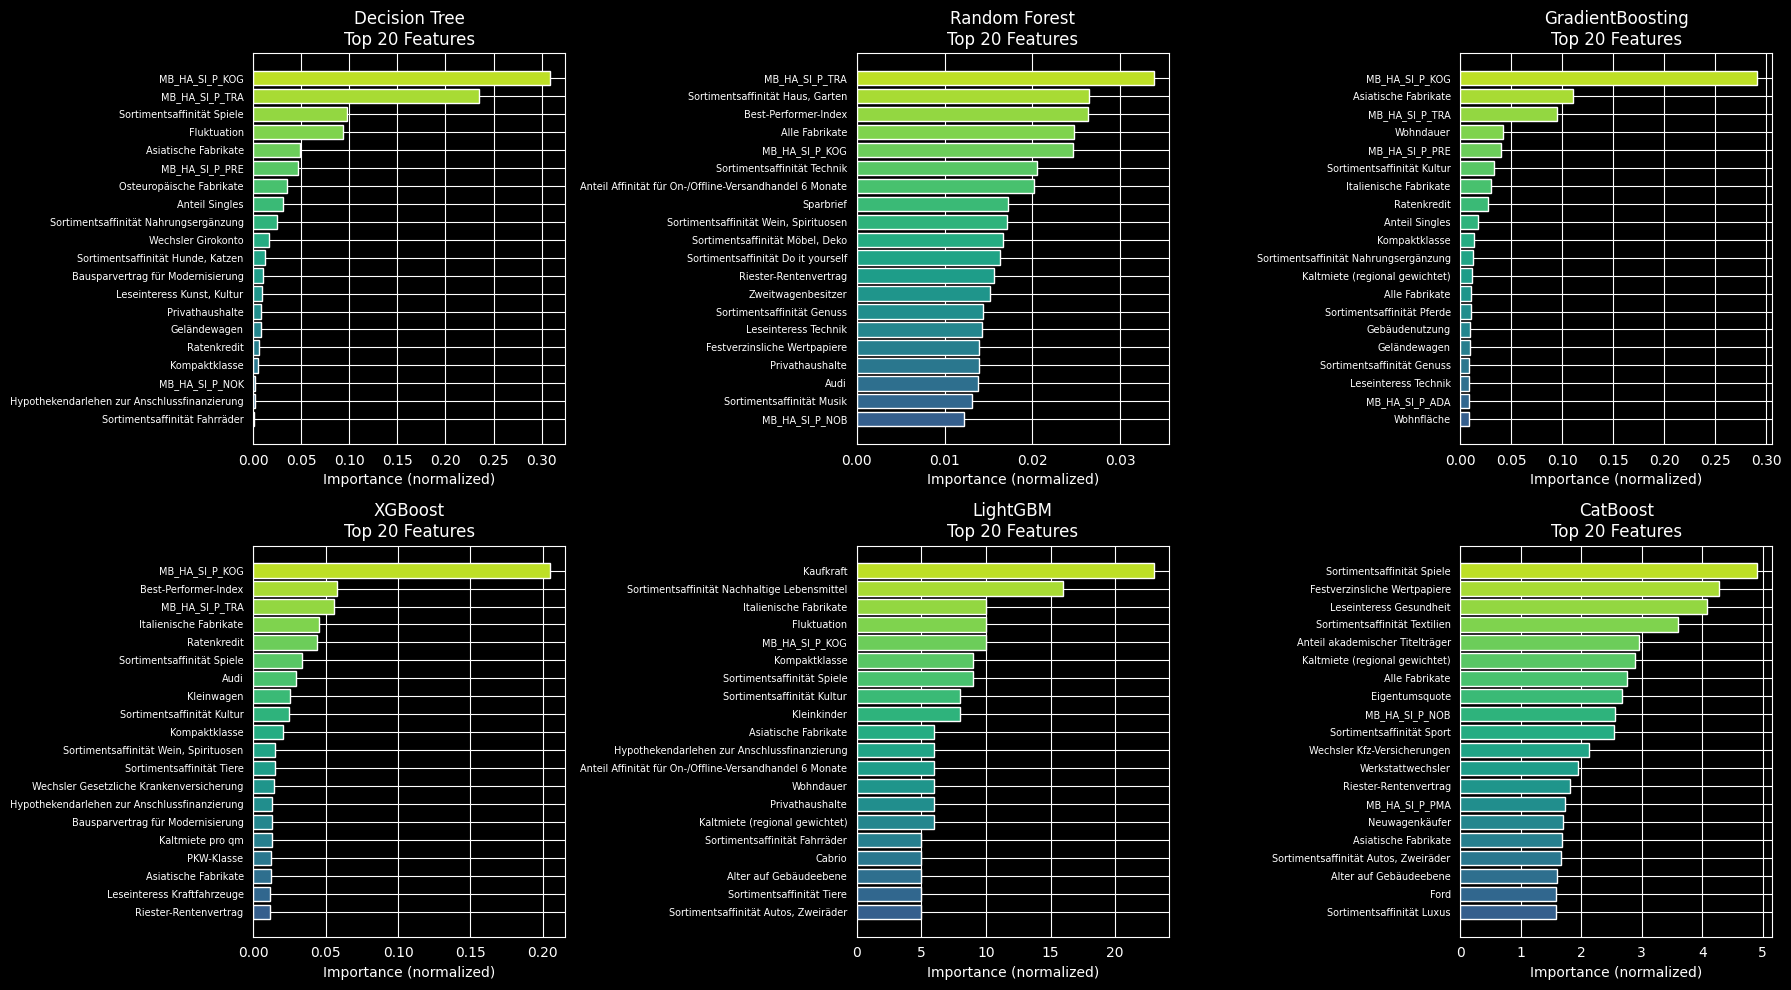

In [26]:
# Per-model feature importance (Top 20)
n_models = len(feature_importance_dict)
n_cols = min(3, n_models)
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = np.array(axes).flatten() if n_models > 1 else [axes]

for idx, (model_name, importance) in enumerate(feature_importance_dict.items()):
    ax = axes[idx]
    
    # Get top 20 features
    top_idx = np.argsort(importance)[-20:]
    top_features = [feature_name_mapping.get(feature_names[i], feature_names[i]) for i in top_idx]
    top_importance = importance[top_idx]
    
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_idx)))
    ax.barh(range(len(top_features)), top_importance, color=colors)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features, fontsize=7)
    ax.set_xlabel('Importance (normalized)')
    ax.set_title(f'{model_name}\nTop 20 Features')

# Hide unused subplots
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance_per_model.png', dpi=150, bbox_inches='tight')
plt.show()

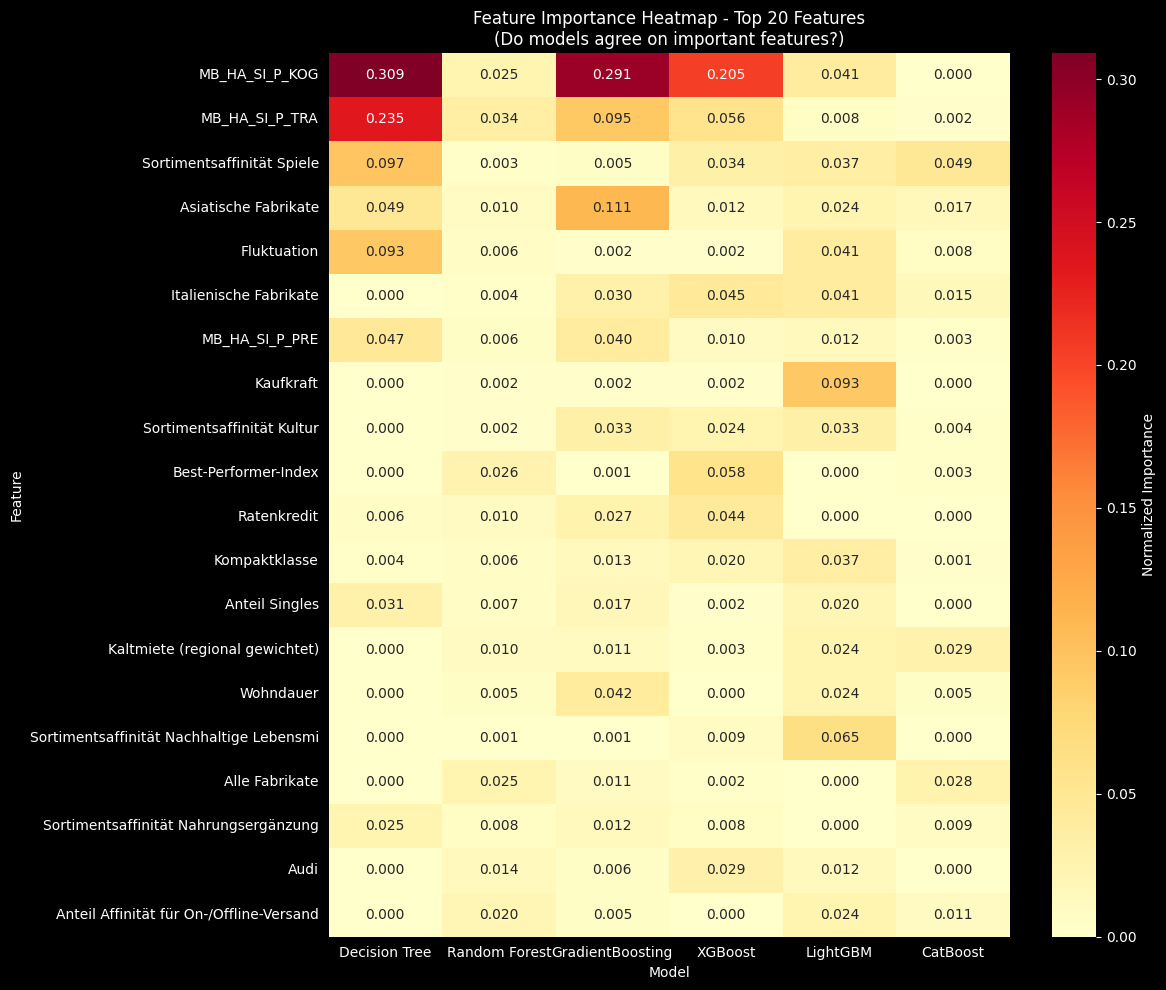

In [27]:
# Feature Importance Heatmap - Top 20 features across models
avg_importance = fi_df.mean(axis=1).sort_values(ascending=False)
top_20_features = avg_importance.head(20).index.tolist()

# Map to original names for display
top_20_display = [feature_name_mapping.get(f, f)[:40] for f in top_20_features]

fi_top20 = fi_df.loc[top_20_features].copy()
fi_top20.index = top_20_display

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(fi_top20, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Normalized Importance'})
ax.set_title('Feature Importance Heatmap - Top 20 Features\n(Do models agree on important features?)')
ax.set_xlabel('Model')
ax.set_ylabel('Feature')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

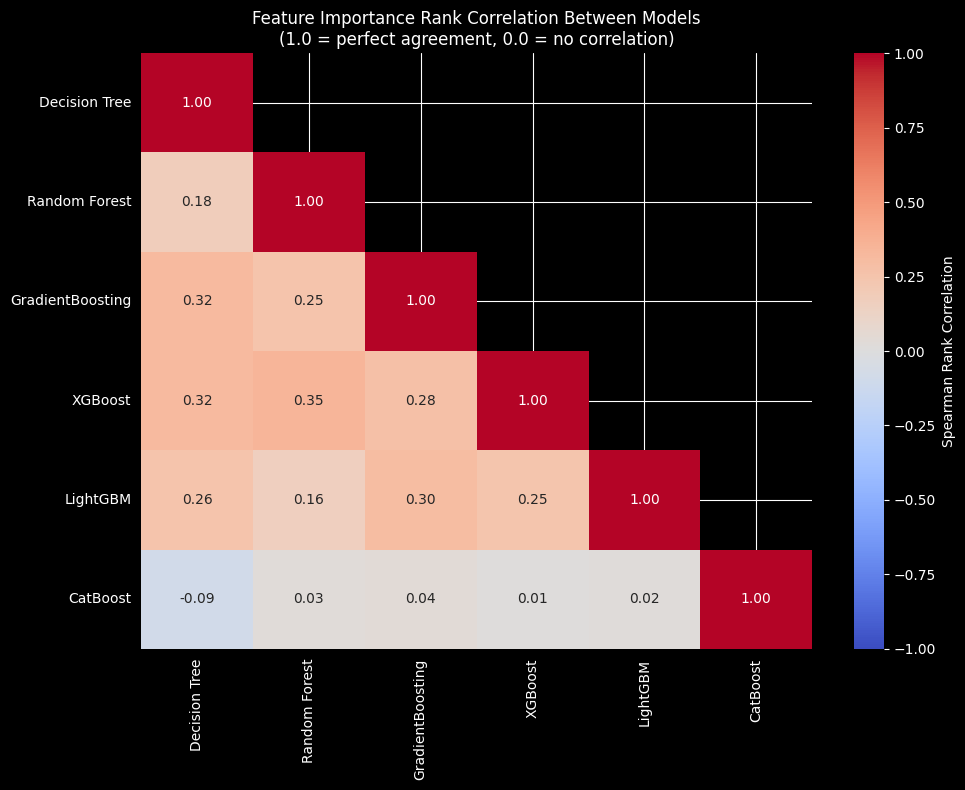


Feature Importance Agreement Summary:
  Mean pairwise correlation: 0.178
  Min pairwise correlation:  -0.091
  Max pairwise correlation:  0.346


In [28]:
# Feature Importance Rank Correlation between models
rank_corr_matrix = fi_df.rank().corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(rank_corr_matrix, dtype=bool), k=1)
sns.heatmap(rank_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, ax=ax, mask=mask,
            cbar_kws={'label': 'Spearman Rank Correlation'})
ax.set_title('Feature Importance Rank Correlation Between Models\n(1.0 = perfect agreement, 0.0 = no correlation)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance_rank_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
lower_tri = rank_corr_matrix.values[np.tril_indices_from(rank_corr_matrix, -1)]
print("\nFeature Importance Agreement Summary:")
print(f"  Mean pairwise correlation: {lower_tri.mean():.3f}")
print(f"  Min pairwise correlation:  {lower_tri.min():.3f}")
print(f"  Max pairwise correlation:  {lower_tri.max():.3f}")

## 2. Prediction Calibration

Are the predicted probabilities well-calibrated? A perfectly calibrated model should have predicted probabilities that match actual frequencies.

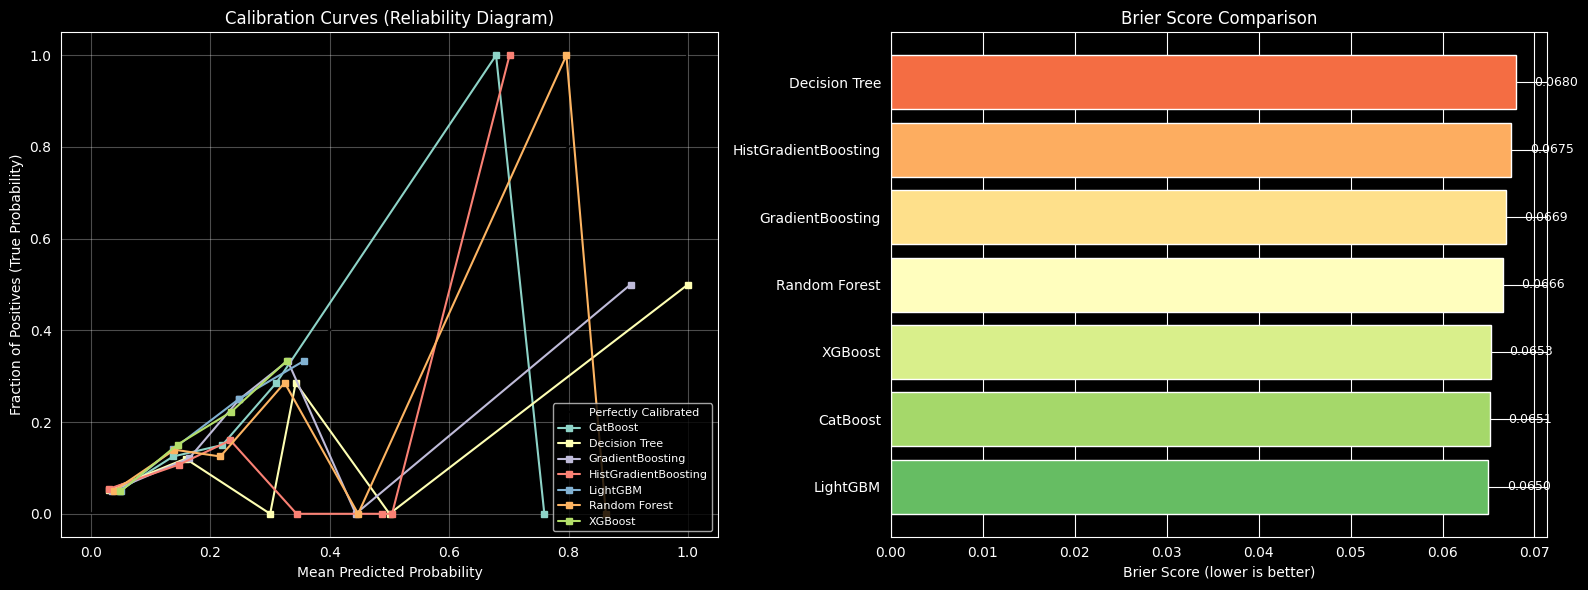

In [29]:
# Calibration Curves (Reliability Diagrams)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Calibration curves
ax1 = axes[0]
ax1.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')

calibration_data = {}
for model_name in sorted(y_probas.keys()):
    y_proba = y_probas[model_name]
    prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='uniform')
    calibration_data[model_name] = {'prob_true': prob_true, 'prob_pred': prob_pred}
    ax1.plot(prob_pred, prob_true, 's-', label=model_name, markersize=5)

ax1.set_xlabel('Mean Predicted Probability')
ax1.set_ylabel('Fraction of Positives (True Probability)')
ax1.set_title('Calibration Curves (Reliability Diagram)')
ax1.legend(loc='lower right', fontsize=8)
ax1.grid(True, alpha=0.3)

# Right: Brier Score comparison
ax2 = axes[1]
brier_scores = {}
for model_name, y_proba in y_probas.items():
    brier_scores[model_name] = brier_score_loss(y_test, y_proba)

brier_sorted = dict(sorted(brier_scores.items(), key=lambda x: x[1]))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(brier_sorted)))

bars = ax2.barh(list(brier_sorted.keys()), list(brier_sorted.values()), color=colors)
ax2.set_xlabel('Brier Score (lower is better)')
ax2.set_title('Brier Score Comparison')

for bar, score in zip(bars, brier_sorted.values()):
    ax2.text(score + 0.002, bar.get_y() + bar.get_height()/2, f'{score:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Expected Calibration Error (ECE)
def expected_calibration_error(y_true, y_prob, n_bins=10):
    """Calculate Expected Calibration Error."""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    
    for i in range(n_bins):
        bin_mask = (y_prob >= bin_boundaries[i]) & (y_prob < bin_boundaries[i + 1])
        if bin_mask.sum() > 0:
            bin_accuracy = y_true[bin_mask].mean()
            bin_confidence = y_prob[bin_mask].mean()
            bin_size = bin_mask.sum() / len(y_true)
            ece += bin_size * abs(bin_accuracy - bin_confidence)
    
    return ece

# Calculate ECE for all models
ece_scores = {}
for model_name, y_proba in y_probas.items():
    ece_scores[model_name] = expected_calibration_error(y_test, y_proba)

# Create calibration summary table
calibration_summary = pd.DataFrame({
    'Model': list(brier_scores.keys()),
    'Brier Score': list(brier_scores.values()),
    'ECE': [ece_scores[m] for m in brier_scores.keys()]
}).sort_values('Brier Score').reset_index(drop=True)

print("="*60)
print("CALIBRATION SUMMARY")
print("="*60)
print("\nBrier Score: Overall accuracy of probabilistic predictions (lower = better)")
print("ECE: Expected Calibration Error (lower = better calibrated)")
display(calibration_summary)

CALIBRATION SUMMARY

Brier Score: Overall accuracy of probabilistic predictions (lower = better)
ECE: Expected Calibration Error (lower = better calibrated)


,Model,Brier Score,ECE
0,LightGBM,0.064995,0.001037
1,CatBoost,0.065115,0.009133
2,XGBoost,0.065297,0.001515
3,Random Forest,0.066556,0.017554
4,GradientBoosting,0.066914,0.023948
5,HistGradientBoosting,0.067484,0.034915
6,Decision Tree,0.067982,0.029610


## 3. Prediction Distribution Analysis

How do models distribute their probability predictions? Do they produce similar or different prediction patterns?

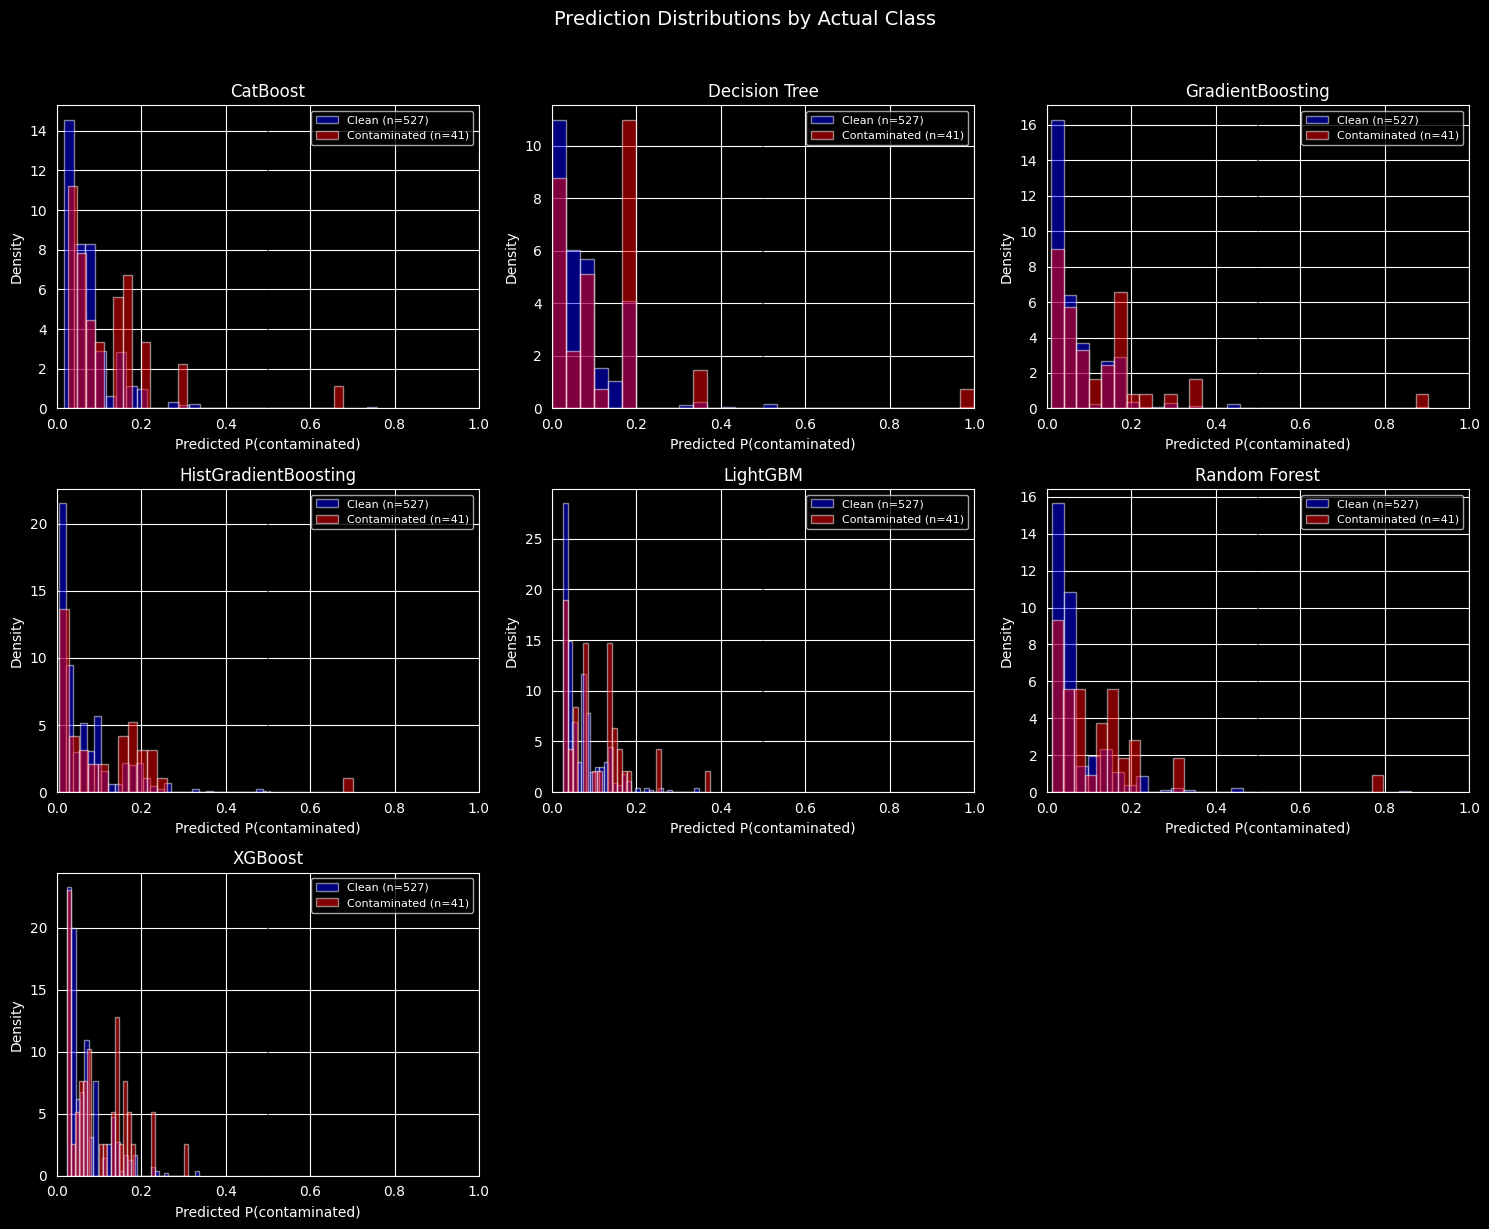

In [31]:
# Prediction Distribution Histograms
n_models = len(y_probas)
n_cols = min(3, n_models)
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.array(axes).flatten() if n_models > 1 else [axes]

for idx, (model_name, y_proba) in enumerate(sorted(y_probas.items())):
    ax = axes[idx]
    
    # Separate by actual class
    proba_pos = y_proba[y_test == 1]
    proba_neg = y_proba[y_test == 0]
    
    ax.hist(proba_neg, bins=30, alpha=0.5, label=f'Clean (n={len(proba_neg)})', color='blue', density=True)
    ax.hist(proba_pos, bins=30, alpha=0.5, label=f'Contaminated (n={len(proba_pos)})', color='red', density=True)
    ax.axvline(0.5, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Predicted P(contaminated)')
    ax.set_ylabel('Density')
    ax.set_title(f'{model_name}')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

# Hide unused
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Prediction Distributions by Actual Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'prediction_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

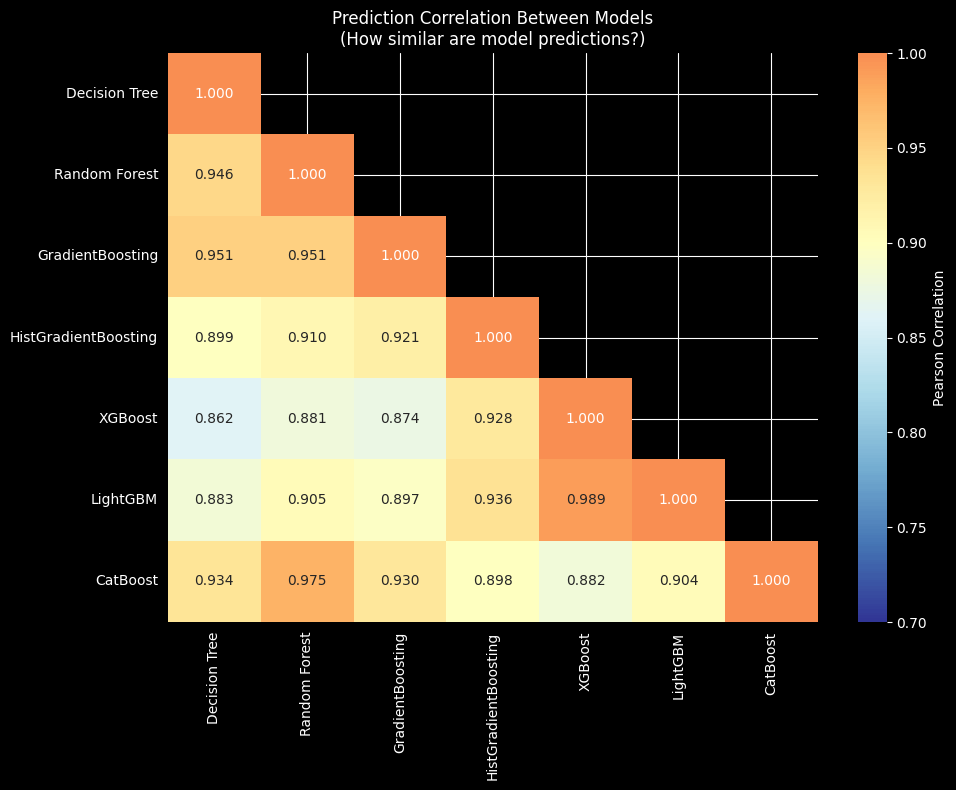


Mean prediction correlation: 0.9170


In [32]:
# Prediction Correlation Heatmap
pred_df = pd.DataFrame(y_probas)
pred_corr = pred_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(pred_corr, dtype=bool), k=1)
sns.heatmap(pred_corr, annot=True, fmt='.3f', cmap='RdYlBu_r', 
            center=0.9, vmin=0.7, vmax=1.0, ax=ax, mask=mask,
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Prediction Correlation Between Models\n(How similar are model predictions?)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'prediction_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

lower_tri = pred_corr.values[np.tril_indices_from(pred_corr, -1)]
print(f"\nMean prediction correlation: {lower_tri.mean():.4f}")

## 4. Extended Performance Metrics

Additional metrics beyond LogLoss and AUC-ROC: Precision-Recall curves, Cumulative Gains, Lift, and KS statistic.

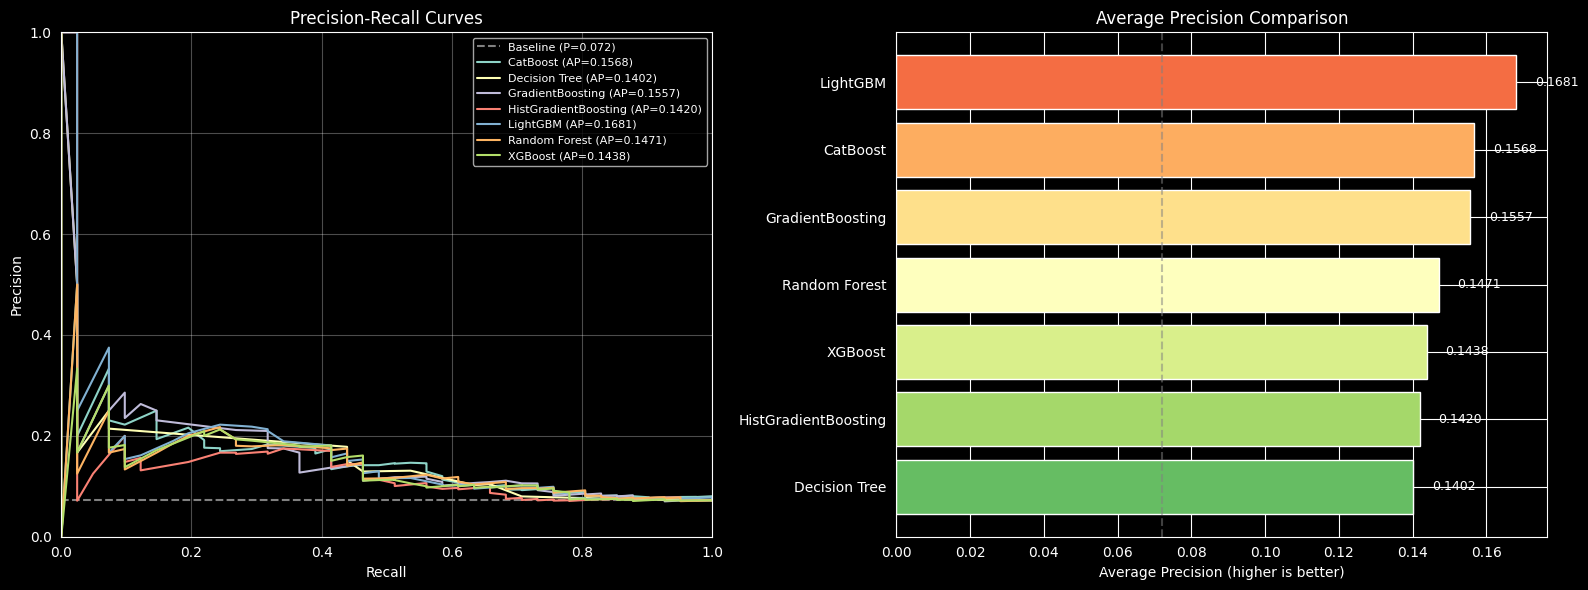

In [33]:
# Precision-Recall Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: PR curves
ax1 = axes[0]
baseline_pr = y_test.mean()
ax1.axhline(baseline_pr, color='gray', linestyle='--', label=f'Baseline (P={baseline_pr:.3f})')

ap_scores = {}
for model_name in sorted(y_probas.keys()):
    y_proba = y_probas[model_name]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    ap_scores[model_name] = ap
    ax1.plot(recall, precision, label=f'{model_name} (AP={ap:.4f})')

ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall Curves')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

# Right: Average Precision comparison
ax2 = axes[1]
ap_sorted = dict(sorted(ap_scores.items(), key=lambda x: x[1], reverse=True))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(ap_sorted)))

bars = ax2.barh(list(ap_sorted.keys()), list(ap_sorted.values()), color=colors)
ax2.set_xlabel('Average Precision (higher is better)')
ax2.set_title('Average Precision Comparison')
ax2.invert_yaxis()
ax2.axvline(baseline_pr, color='gray', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')

for bar, ap in zip(bars, ap_sorted.values()):
    ax2.text(ap + 0.005, bar.get_y() + bar.get_height()/2, f'{ap:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()

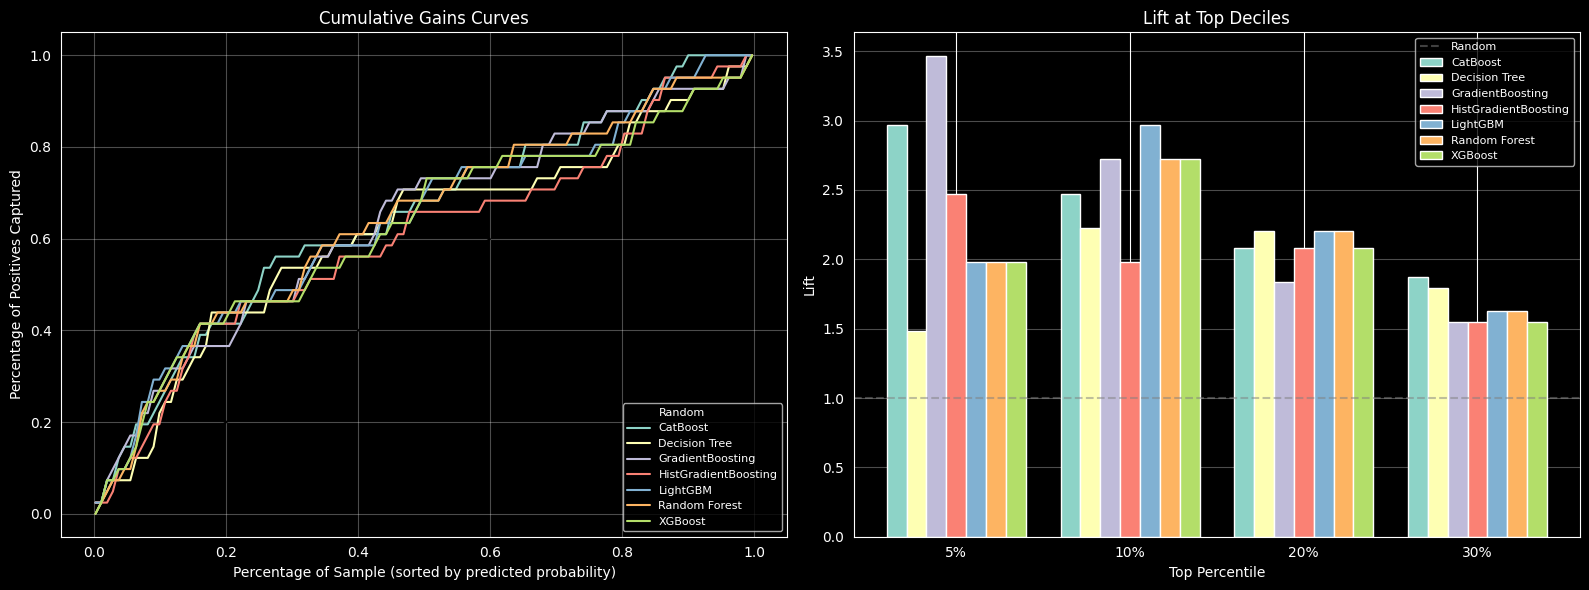

In [34]:
# Cumulative Gains and Lift Curves
def cumulative_gains(y_true, y_prob):
    """Calculate cumulative gains curve data."""
    sorted_idx = np.argsort(y_prob)[::-1]
    y_sorted = y_true[sorted_idx]
    
    cumsum = np.cumsum(y_sorted)
    total_positives = y_sorted.sum()
    
    gains = cumsum / total_positives if total_positives > 0 else cumsum
    percentile = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
    
    return percentile, gains

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Cumulative Gains
ax1 = axes[0]
ax1.plot([0, 1], [0, 1], 'k--', label='Random')

for model_name in sorted(y_probas.keys()):
    y_proba = y_probas[model_name]
    percentile, gains = cumulative_gains(y_test, y_proba)
    step = max(1, len(percentile) // 100)
    ax1.plot(percentile[::step], gains[::step], label=model_name)

ax1.set_xlabel('Percentage of Sample (sorted by predicted probability)')
ax1.set_ylabel('Percentage of Positives Captured')
ax1.set_title('Cumulative Gains Curves')
ax1.legend(loc='lower right', fontsize=8)
ax1.grid(True, alpha=0.3)

# Right: Lift at top deciles
ax2 = axes[1]
deciles = [0.05, 0.10, 0.20, 0.30]
lift_data = {}

for model_name in sorted(y_probas.keys()):
    y_proba = y_probas[model_name]
    sorted_idx = np.argsort(y_proba)[::-1]
    y_sorted = y_test[sorted_idx]
    
    base_rate = y_test.mean()
    lifts = []
    for d in deciles:
        n = int(len(y_sorted) * d)
        if n > 0:
            decile_rate = y_sorted[:n].mean()
            lift = decile_rate / base_rate if base_rate > 0 else 0
            lifts.append(lift)
        else:
            lifts.append(0)
    lift_data[model_name] = lifts

x = np.arange(len(deciles))
width = 0.8 / len(lift_data)

for i, (model_name, lifts) in enumerate(lift_data.items()):
    ax2.bar(x + i * width, lifts, width, label=model_name)

ax2.axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='Random')
ax2.set_xlabel('Top Percentile')
ax2.set_ylabel('Lift')
ax2.set_title('Lift at Top Deciles')
ax2.set_xticks(x + width * (len(lift_data) - 1) / 2)
ax2.set_xticklabels([f'{int(d*100)}%' for d in deciles])
ax2.legend(fontsize=8, loc='upper right')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cumulative_gains_lift.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# Comprehensive Metrics Summary Table
def ks_statistic(y_true, y_prob):
    """Calculate KS statistic."""
    sorted_idx = np.argsort(y_prob)
    y_sorted = y_true[sorted_idx]
    
    n_pos = y_sorted.sum()
    n_neg = len(y_sorted) - n_pos
    
    if n_pos == 0 or n_neg == 0:
        return 0
    
    tpr = np.cumsum(y_sorted) / n_pos
    fpr = np.cumsum(1 - y_sorted) / n_neg
    
    return np.max(np.abs(tpr - fpr))

# Calculate all metrics
comprehensive_metrics = []
for model_name, y_proba in y_probas.items():
    y_pred = (y_proba >= 0.5).astype(int)
    
    metrics = {
        'Model': model_name,
        'LogLoss': log_loss(y_test, y_proba),
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'Avg Precision': average_precision_score(y_test, y_proba),
        'Brier Score': brier_score_loss(y_test, y_proba),
        'ECE': expected_calibration_error(y_test, y_proba),
        'KS Statistic': ks_statistic(y_test, y_proba),
        'F1 (@ 0.5)': f1_score(y_test, y_pred),
        'Lift @ 10%': lift_data[model_name][1],
    }
    comprehensive_metrics.append(metrics)

comprehensive_df = pd.DataFrame(comprehensive_metrics)
comprehensive_df = comprehensive_df.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

print("="*80)
print("COMPREHENSIVE METRICS SUMMARY")
print("="*80)
display(comprehensive_df)

# Save to CSV
comprehensive_df.to_csv(OUTPUT_DIR / 'comprehensive_metrics.csv', index=False)

COMPREHENSIVE METRICS SUMMARY


,Model,LogLoss,AUC-ROC,Avg Precision,Brier Score,ECE,KS Statistic,F1 (@ 0.5),Lift @ 10%
0,CatBoost,0.247728,0.659023,0.156794,0.065115,0.009133,0.312399,0.046512,2.473868
1,Random Forest,0.255887,0.648841,0.147073,0.066556,0.017554,0.279632,0.046512,2.721254
2,GradientBoosting,0.262593,0.646596,0.155695,0.066914,0.023948,0.267089,0.046512,2.721254
3,LightGBM,0.249927,0.645879,0.168126,0.064995,0.001037,0.278012,0.000000,2.968641
4,XGBoost,0.250960,0.631369,0.143834,0.065297,0.001515,0.277456,0.000000,2.721254
5,Decision Tree,0.607904,0.630884,0.140202,0.067982,0.029610,0.281529,0.043478,2.226481
6,HistGradientBoosting,0.280648,0.608159,0.142005,0.067484,0.034915,0.274217,0.046512,1.979094


## 5. Inference Speed Benchmark

Training is one-time, but prediction happens repeatedly. How fast can each model make predictions?

INFERENCE SPEED BENCHMARK
Decision Tree: 0.59 ± 0.09 ms for 568 samples
Random Forest: 32.48 ± 19.06 ms for 568 samples
GradientBoosting: 0.92 ± 0.08 ms for 568 samples
HistGradientBoosting: 1.28 ± 0.07 ms for 568 samples
XGBoost: 16.80 ± 1.61 ms for 568 samples
LightGBM: 0.90 ± 0.29 ms for 568 samples
CatBoost: 0.71 ± 0.03 ms for 568 samples


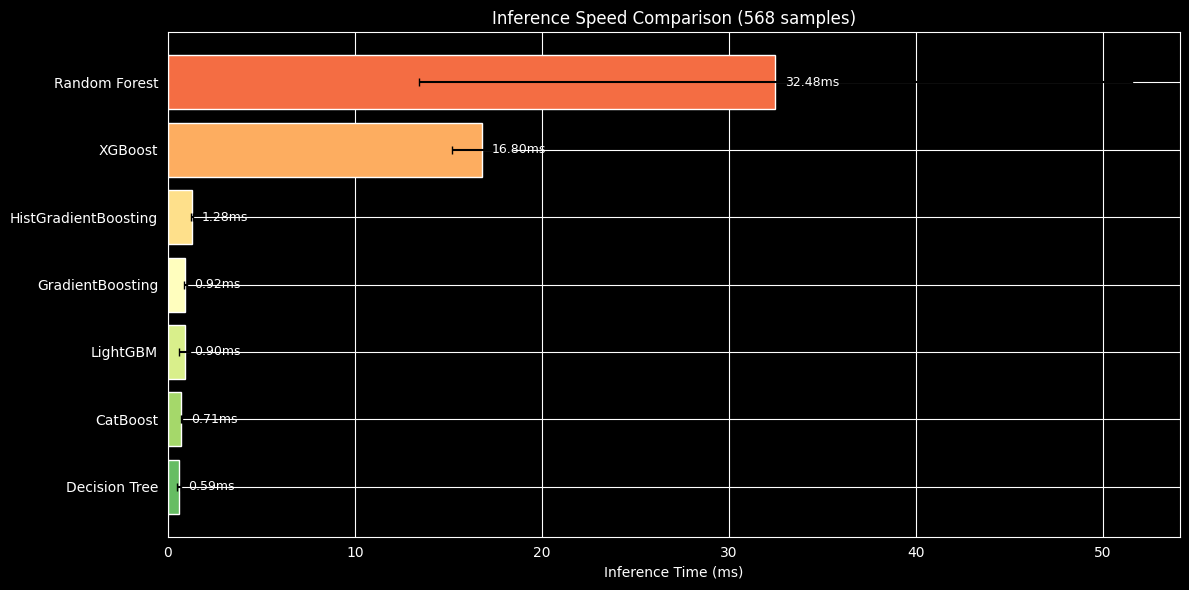

In [36]:
# Inference Speed Benchmark
print("="*60)
print("INFERENCE SPEED BENCHMARK")
print("="*60)

n_samples_batch = min(1000, len(X_test))
n_repeats = 10

inference_times = {}
test_batch = X_test.iloc[:n_samples_batch]

for model_name, model in trained_models.items():
    # Warmup
    _ = model.predict_proba(test_batch)
    
    # Timed runs
    times = []
    for _ in range(n_repeats):
        start = time.time()
        _ = model.predict_proba(test_batch)
        times.append(time.time() - start)
    
    avg_time = np.mean(times)
    std_time = np.std(times)
    inference_times[model_name] = {
        'batch_time_ms': avg_time * 1000,
        'std_ms': std_time * 1000,
        'samples_per_sec': n_samples_batch / avg_time
    }
    print(f"{model_name}: {avg_time*1000:.2f} ± {std_time*1000:.2f} ms for {n_samples_batch} samples")

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

models = list(inference_times.keys())
times_ms = [inference_times[m]['batch_time_ms'] for m in models]
stds = [inference_times[m]['std_ms'] for m in models]

# Sort by speed
sorted_idx = np.argsort(times_ms)
models = [models[i] for i in sorted_idx]
times_ms = [times_ms[i] for i in sorted_idx]
stds = [stds[i] for i in sorted_idx]

colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(models)))
bars = ax.barh(models, times_ms, xerr=stds, color=colors, capsize=3)
ax.set_xlabel('Inference Time (ms)')
ax.set_title(f'Inference Speed Comparison ({n_samples_batch} samples)')

for bar, t in zip(bars, times_ms):
    ax.text(t + 0.5, bar.get_y() + bar.get_height()/2, f'{t:.2f}ms', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'inference_speed.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Training Convergence

How does loss decrease during training? When does early stopping trigger?

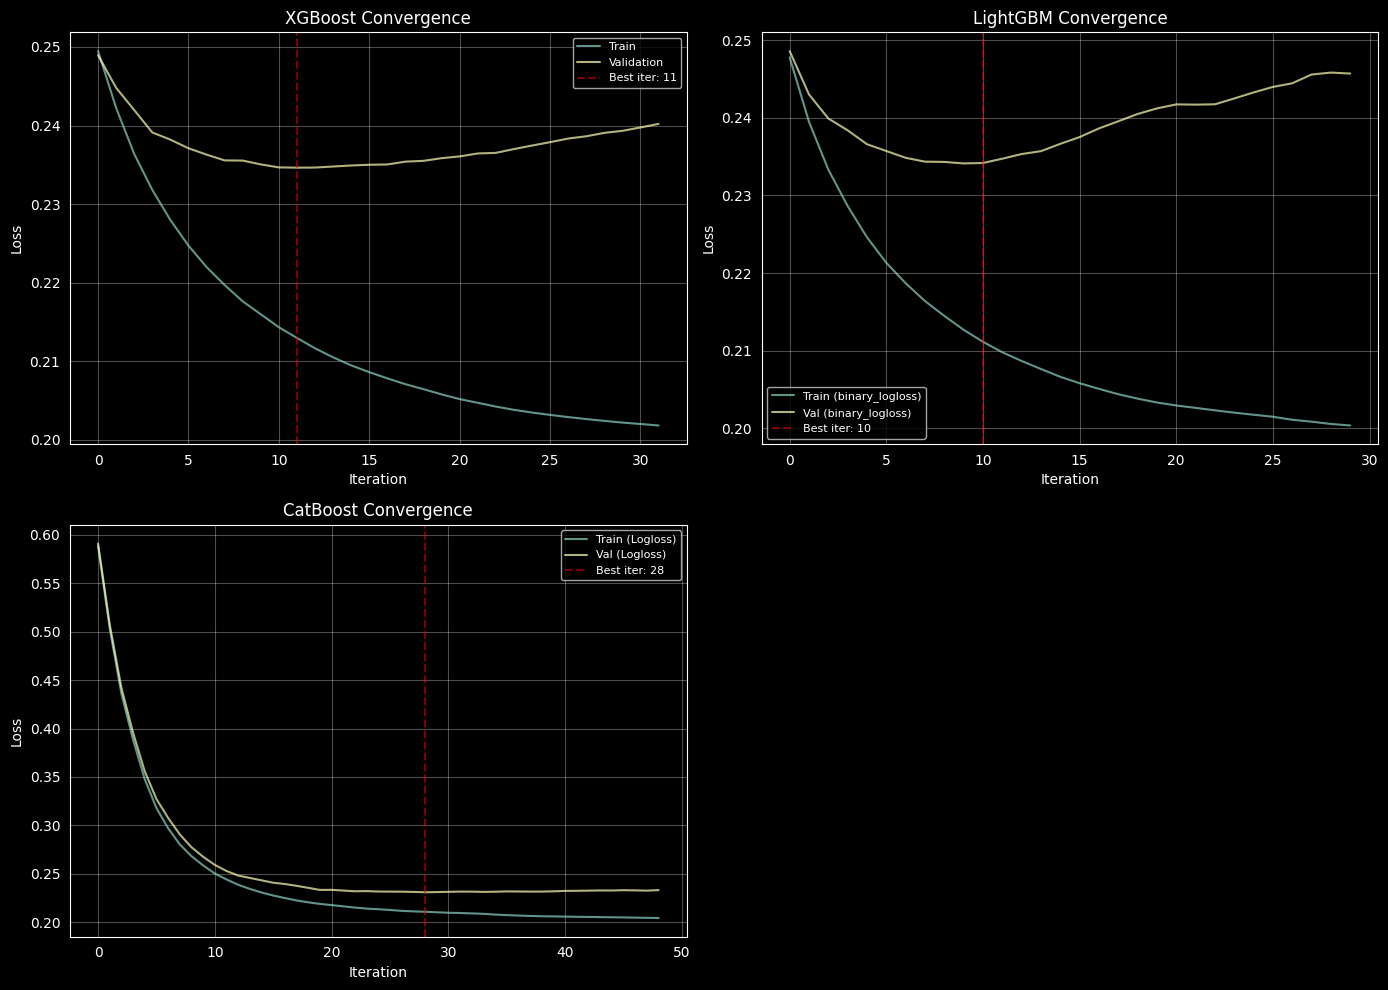

In [37]:
# Training Convergence Plots
n_histories = len(eval_histories)
if n_histories > 0:
    n_cols = min(2, n_histories)
    n_rows = (n_histories + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = np.array(axes).flatten() if n_histories > 1 else [axes]
    
    plot_idx = 0
    
    for model_name, history in eval_histories.items():
        if plot_idx >= len(axes):
            break
        ax = axes[plot_idx]
        
        if 'XGBoost' in model_name:
            # XGBoost format: {'validation_0': {'logloss': [...]}, 'validation_1': {...}}
            if 'validation_0' in history:
                train_loss = history['validation_0']['logloss']
                ax.plot(train_loss, label='Train', alpha=0.7)
            if 'validation_1' in history:
                val_loss = history['validation_1']['logloss']
                ax.plot(val_loss, label='Validation', alpha=0.7)
                if hasattr(trained_models[model_name], 'best_iteration'):
                    best_iter = trained_models[model_name].best_iteration
                    if best_iter < len(val_loss):
                        ax.axvline(best_iter, color='red', linestyle='--', alpha=0.5, label=f'Best iter: {best_iter}')
        
        elif 'LightGBM' in model_name:
            # LightGBM format: {'training': {'binary_logloss': [...]}, 'valid_1': {...}}
            if 'training' in history:
                for metric_name, values in history['training'].items():
                    ax.plot(values, label=f'Train ({metric_name})', alpha=0.7)
            if 'valid_1' in history:
                for metric_name, values in history['valid_1'].items():
                    ax.plot(values, label=f'Val ({metric_name})', alpha=0.7)
                if hasattr(trained_models[model_name], 'best_iteration_'):
                    best_iter = trained_models[model_name].best_iteration_
                    ax.axvline(best_iter, color='red', linestyle='--', alpha=0.5, label=f'Best iter: {best_iter}')
        
        elif 'CatBoost' in model_name:
            # CatBoost format: {'learn': {'Logloss': [...]}, 'validation': {...}}
            if 'learn' in history:
                for metric_name, values in history['learn'].items():
                    ax.plot(values, label=f'Train ({metric_name})', alpha=0.7)
            if 'validation' in history:
                for metric_name, values in history['validation'].items():
                    ax.plot(values, label=f'Val ({metric_name})', alpha=0.7)
                if hasattr(trained_models[model_name], 'best_iteration_'):
                    best_iter = trained_models[model_name].best_iteration_
                    ax.axvline(best_iter, color='red', linestyle='--', alpha=0.5, label=f'Best iter: {best_iter}')
        
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Loss')
        ax.set_title(f'{model_name} Convergence')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        plot_idx += 1
    
    # Hide unused
    for idx in range(plot_idx, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'training_convergence.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No training histories available for convergence plots.")

## 7. Model Agreement Analysis

Do models make similar predictions? Where do they disagree? Could ensembling improve results?

MODEL AGREEMENT ANALYSIS

Pairwise Agreement Rate at threshold=0.5:


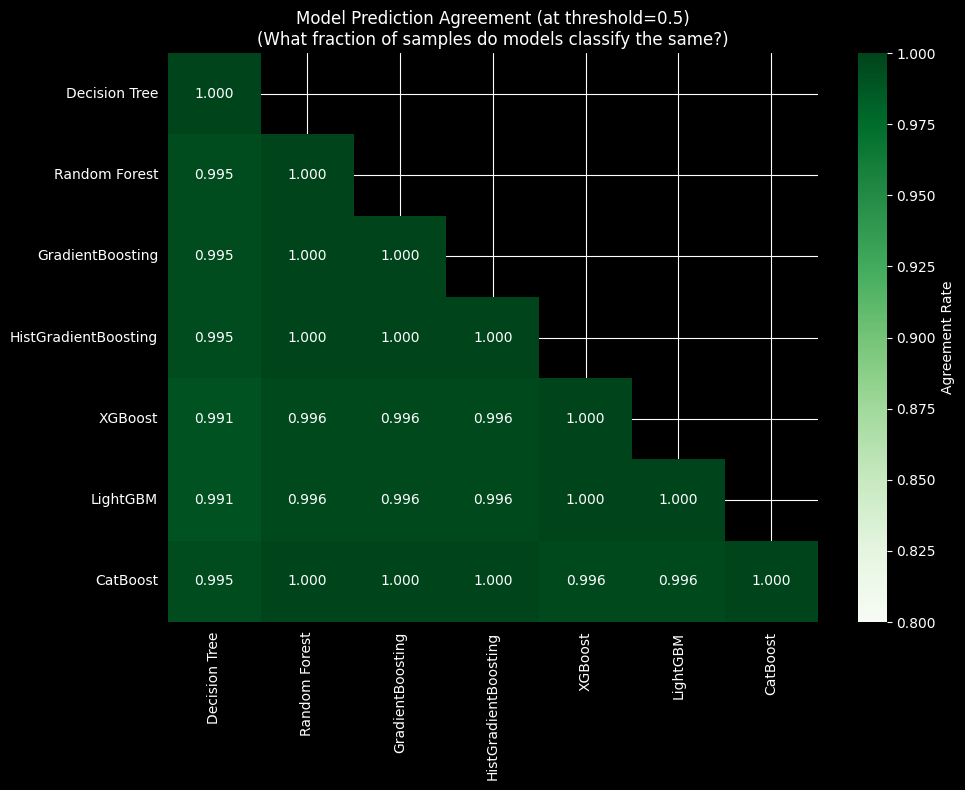

In [38]:
# Model Agreement Analysis
print("="*60)
print("MODEL AGREEMENT ANALYSIS")
print("="*60)

model_names_list = list(y_probas.keys())

print("\nPairwise Agreement Rate at threshold=0.5:")
agreement_matrix = pd.DataFrame(index=model_names_list, columns=model_names_list, dtype=float)

for i, m1 in enumerate(model_names_list):
    for j, m2 in enumerate(model_names_list):
        pred1 = (y_probas[m1] >= 0.5).astype(int)
        pred2 = (y_probas[m2] >= 0.5).astype(int)
        agreement = (pred1 == pred2).mean()
        agreement_matrix.loc[m1, m2] = agreement

# Plot agreement matrix
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(agreement_matrix.astype(float), dtype=bool), k=1)
sns.heatmap(agreement_matrix.astype(float), annot=True, fmt='.3f', cmap='Greens',
            vmin=0.8, vmax=1.0, ax=ax, mask=mask,
            cbar_kws={'label': 'Agreement Rate'})
ax.set_title('Model Prediction Agreement (at threshold=0.5)\n(What fraction of samples do models classify the same?)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_agreement.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# Ensemble Averaging Experiment
print("="*60)
print("ENSEMBLE AVERAGING EXPERIMENT")
print("="*60)

ensemble_results = []

# 1. Simple average of all models
all_avg = pred_df.mean(axis=1).values
ensemble_results.append({
    'Ensemble': 'All Models Average',
    'LogLoss': log_loss(y_test, all_avg),
    'AUC': roc_auc_score(y_test, all_avg)
})

# 2. Top 3 models average
top3_models = results_df.head(3)['Model'].tolist()
if len(top3_models) >= 3:
    top3_avg = pred_df[top3_models].mean(axis=1).values
    ensemble_results.append({
        'Ensemble': f'Top 3 Average',
        'LogLoss': log_loss(y_test, top3_avg),
        'AUC': roc_auc_score(y_test, top3_avg)
    })

# 3. Best single model for comparison
best_model = results_df.iloc[0]['Model']
ensemble_results.append({
    'Ensemble': f'Best Single ({best_model})',
    'LogLoss': log_loss(y_test, y_probas[best_model]),
    'AUC': roc_auc_score(y_test, y_probas[best_model])
})

ensemble_df = pd.DataFrame(ensemble_results).sort_values('AUC', ascending=False).reset_index(drop=True)

print("\nEnsemble vs Best Single Model:")
display(ensemble_df)

# Determine if ensembling helps
best_single_auc = results_df.iloc[0]['AUC']
best_ensemble_auc = ensemble_df['AUC'].max()
if best_ensemble_auc > best_single_auc:
    print(f"\nEnsembling improves AUC by {(best_ensemble_auc - best_single_auc)*100:.3f}%")
else:
    print(f"\nBest single model ({best_model}) outperforms ensembles.")

ENSEMBLE AVERAGING EXPERIMENT

Ensemble vs Best Single Model:


,Ensemble,LogLoss,AUC
0,Best Single (CatBoost),0.247728,0.659023
1,Top 3 Average,0.253065,0.650599
2,All Models Average,0.254845,0.637594



Best single model (CatBoost) outperforms ensembles.


## 8. Statistical Significance Tests

Are the differences between models statistically significant? Bootstrap confidence intervals and paired tests.

In [40]:
# Bootstrap Confidence Intervals for AUC
print("="*60)
print("BOOTSTRAP CONFIDENCE INTERVALS (95%)")
print("="*60)

def bootstrap_metric(y_true, y_proba, metric_func, n_bootstrap=500, ci=0.95):
    """Calculate bootstrap confidence intervals for a metric."""
    np.random.seed(RANDOM_STATE)
    n_samples = len(y_true)
    bootstrap_scores = []
    
    for _ in range(n_bootstrap):
        idx = np.random.choice(n_samples, size=n_samples, replace=True)
        try:
            score = metric_func(y_true[idx], y_proba[idx])
            bootstrap_scores.append(score)
        except:
            continue
    
    bootstrap_scores = np.array(bootstrap_scores)
    lower = np.percentile(bootstrap_scores, (1 - ci) / 2 * 100)
    upper = np.percentile(bootstrap_scores, (1 + ci) / 2 * 100)
    mean = bootstrap_scores.mean()
    std = bootstrap_scores.std()
    
    return {'mean': mean, 'std': std, 'lower': lower, 'upper': upper}

# Calculate CIs for all models
n_bootstrap = 500

bootstrap_results = []
for model_name in y_probas.keys():
    y_proba = y_probas[model_name]
    
    auc_ci = bootstrap_metric(y_test, y_proba, roc_auc_score, n_bootstrap)
    ll_ci = bootstrap_metric(y_test, y_proba, log_loss, n_bootstrap)
    
    bootstrap_results.append({
        'Model': model_name,
        'AUC Mean': auc_ci['mean'],
        'AUC 95% CI': f"[{auc_ci['lower']:.4f}, {auc_ci['upper']:.4f}]",
        'LogLoss Mean': ll_ci['mean'],
        'LogLoss 95% CI': f"[{ll_ci['lower']:.4f}, {ll_ci['upper']:.4f}]"
    })
    print(f"{model_name}:")
    print(f"  AUC:     {auc_ci['mean']:.4f} [{auc_ci['lower']:.4f}, {auc_ci['upper']:.4f}]")
    print(f"  LogLoss: {ll_ci['mean']:.4f} [{ll_ci['lower']:.4f}, {ll_ci['upper']:.4f}]")

bootstrap_df = pd.DataFrame(bootstrap_results)
bootstrap_df.to_csv(OUTPUT_DIR / 'bootstrap_confidence_intervals.csv', index=False)

BOOTSTRAP CONFIDENCE INTERVALS (95%)
Decision Tree:
  AUC:     0.6279 [0.5255, 0.7286]
  LogLoss: 0.6090 [0.3237, 0.9368]
Random Forest:
  AUC:     0.6456 [0.5433, 0.7422]
  LogLoss: 0.2569 [0.1956, 0.3196]
GradientBoosting:
  AUC:     0.6444 [0.5429, 0.7343]
  LogLoss: 0.2635 [0.1986, 0.3282]
HistGradientBoosting:
  AUC:     0.6065 [0.5080, 0.7087]
  LogLoss: 0.2815 [0.2106, 0.3549]
XGBoost:
  AUC:     0.6285 [0.5223, 0.7304]
  LogLoss: 0.2517 [0.1941, 0.3103]
LightGBM:
  AUC:     0.6431 [0.5443, 0.7378]
  LogLoss: 0.2507 [0.1941, 0.3080]
CatBoost:
  AUC:     0.6564 [0.5589, 0.7503]
  LogLoss: 0.2485 [0.1930, 0.3042]


In [41]:
# McNemar's Test for pairwise model comparison
print("="*60)
print("McNEMAR'S TEST: Pairwise Model Comparison")
print("="*60)
print("\nTests whether two models make significantly different errors.")
print("Null hypothesis: Models have equal error rates.")
print("p < 0.05 suggests statistically significant difference.\n")

def mcnemar_test(y_true, pred1, pred2):
    """
    McNemar's test for comparing two classifiers.
    Returns chi-squared statistic and p-value.
    """
    # Contingency table
    # b = model1 correct, model2 wrong
    # c = model1 wrong, model2 correct
    b = np.sum((pred1 == y_true) & (pred2 != y_true))
    c = np.sum((pred1 != y_true) & (pred2 == y_true))
    
    # McNemar's test with continuity correction
    if b + c == 0:
        return 0, 1.0  # No disagreement
    
    chi2 = (abs(b - c) - 1) ** 2 / (b + c)
    p_value = 1 - stats.chi2.cdf(chi2, df=1)
    
    return chi2, p_value

# Compare models
comparison_models = list(y_probas.keys())
mcnemar_results = []

for i, m1 in enumerate(comparison_models):
    for m2 in comparison_models[i+1:]:
        pred1 = (y_probas[m1] >= 0.5).astype(int)
        pred2 = (y_probas[m2] >= 0.5).astype(int)
        
        chi2, p_value = mcnemar_test(y_test, pred1, pred2)
        sig = "*" if p_value < 0.05 else ""
        
        mcnemar_results.append({
            'Model 1': m1,
            'Model 2': m2,
            'Chi-squared': chi2,
            'p-value': p_value,
            'Significant': p_value < 0.05
        })
        print(f"{m1} vs {m2}: chi2={chi2:.3f}, p={p_value:.4f} {sig}")

mcnemar_df = pd.DataFrame(mcnemar_results)
mcnemar_df.to_csv(OUTPUT_DIR / 'mcnemar_tests.csv', index=False)

n_significant = mcnemar_df['Significant'].sum()
n_total = len(mcnemar_df)
print(f"\n{n_significant}/{n_total} pairwise comparisons are statistically significant (p < 0.05)")

McNEMAR'S TEST: Pairwise Model Comparison

Tests whether two models make significantly different errors.
Null hypothesis: Models have equal error rates.
p < 0.05 suggests statistically significant difference.

Decision Tree vs Random Forest: chi2=1.333, p=0.2482 
Decision Tree vs GradientBoosting: chi2=1.333, p=0.2482 
Decision Tree vs HistGradientBoosting: chi2=1.333, p=0.2482 
Decision Tree vs XGBoost: chi2=0.800, p=0.3711 
Decision Tree vs LightGBM: chi2=0.800, p=0.3711 
Decision Tree vs CatBoost: chi2=1.333, p=0.2482 
Random Forest vs GradientBoosting: chi2=0.000, p=1.0000 
Random Forest vs HistGradientBoosting: chi2=0.000, p=1.0000 
Random Forest vs XGBoost: chi2=0.500, p=0.4795 
Random Forest vs LightGBM: chi2=0.500, p=0.4795 
Random Forest vs CatBoost: chi2=0.000, p=1.0000 
GradientBoosting vs HistGradientBoosting: chi2=0.000, p=1.0000 
GradientBoosting vs XGBoost: chi2=0.500, p=0.4795 
GradientBoosting vs LightGBM: chi2=0.500, p=0.4795 
GradientBoosting vs CatBoost: chi2=0.000,

## Summary & Output Files

### Key Findings

This benchmark compared 7 gradient boosting implementations on the Scantec bio waste contamination dataset:

1. **Dataset Characteristics**:
   - ~2,848 samples (small dataset)
   - 149 geodemographic features from Post Direkt
   - Severe class imbalance (~7% contaminated)

2. **Model Performance**:
   - Primary metric: ROC-AUC (due to class imbalance)
   - Baseline AUC: 0.5 (random guessing)
   - See results table for detailed comparison

3. **Practical Implications**:
   - If AUC > 0.65: Geodemographics have predictive power for contamination
   - Top features reveal which demographic factors correlate with contamination
   - Could guide targeted education campaigns in high-risk areas

### Output Files Generated

All outputs saved to `outputs/` directory:
- `scantec_benchmark_YYYYMMDD_HHMMSS.csv` - Main results
- `comprehensive_metrics.csv` - Extended metrics
- `bootstrap_confidence_intervals.csv` - Statistical CIs
- `mcnemar_tests.csv` - Pairwise significance tests
- Various PNG visualizations

In [42]:
# Final summary
print("="*80)
print("SCANTEC GBDT BENCHMARK COMPLETE")
print("="*80)

print(f"\nDataset: {len(df):,} samples, {len(feature_names)} features")
print(f"Class imbalance: {y.mean()*100:.2f}% positive (contaminated)")

print(f"\nBest Model: {results_df.iloc[0]['Model']}")
print(f"  AUC:     {results_df.iloc[0]['AUC']:.4f}")
print(f"  LogLoss: {results_df.iloc[0]['LogLoss']:.4f}")

print(f"\nBaseline Comparison:")
print(f"  AUC improvement over random: +{(results_df.iloc[0]['AUC'] - 0.5)*100:.2f}%")

print(f"\nOutput files saved to: {OUTPUT_DIR.absolute()}")
for f in OUTPUT_DIR.glob('*'):
    print(f"  - {f.name}")

SCANTEC GBDT BENCHMARK COMPLETE

Dataset: 2,840 samples, 149 features
Class imbalance: 7.18% positive (contaminated)

Best Model: CatBoost
  AUC:     0.6590
  LogLoss: 0.2477

Baseline Comparison:
  AUC improvement over random: +15.90%

Output files saved to: /home/ghost/Repositories/Scripts-and-Notebooks/data_science/Extreme and Light Gradient Boosting Ensemble/outputs
  - geodemo_evaluation_results.json
  - geodemo_confusion_matrices.png
  - geodemo_feature_importance.png
  - model_comparison_bars.png
  - roc_curves.png
  - scantec_benchmark_20260120_085242.csv
  - feature_importance_per_model.png
  - feature_importance_heatmap.png
  - feature_importance_rank_correlation.png
  - calibration_curves.png
  - prediction_distributions.png
  - prediction_correlation.png
  - precision_recall_curves.png
  - cumulative_gains_lift.png
  - comprehensive_metrics.csv
  - inference_speed.png
  - training_convergence.png
  - model_agreement.png
  - bootstrap_confidence_intervals.csv
  - mcnemar_tes